# Handwritten Digits Detection using MNIST

First we load the dataset using torchvision. We can display some samples from it by squeezing down the tensor images. MNIST stores the data as packed ubyte for performance. We will be roughly following [this quickstart](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html).

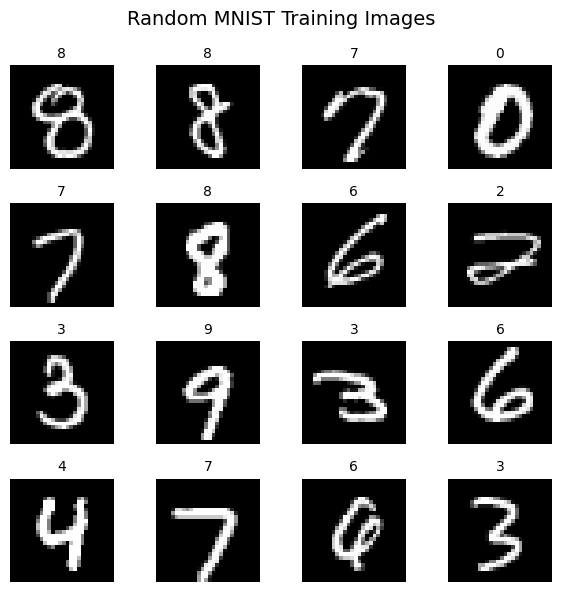

In [1]:
import torch
import random
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=ToTensor()
)

# Display some random images.
indices = random.sample(range(len(training_data)), 16)
fig, axes = plt.subplots(4, 4, figsize=(6, 6))
fig.suptitle("Random MNIST Training Images", fontsize=14)

for ax, idx in zip(axes.flat, indices):
    image, label = training_data[idx]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"{label}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

By batching the data in chunks of 64, we make it more efficient for the GPU and for the gradient computation. Small steps will be very noisy. This is done by dataloaders. They support many more forms of iterating and grouping data in datasets.

In [2]:
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


We can train the data using either the CPU or with an accelerator. This can be queried. It will speed up calculations when using a GPU. See [`torch.device`](https://docs.pytorch.org/docs/stable/tensor_attributes.html#torch.device) and [`torch.accelerator`](https://docs.pytorch.org/docs/stable/torch.html#accelerators). If you want acceleration, you must download the CUDA-enabled version of torch [here](https://pytorch.org/get-started/locally/). You can verify the highest supported CUDA version for nvidia by running `nvidia-smi`.

In [3]:
device = "cpu"
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator()
print (f"Using device \"{device}\"")

Using device "cpu"


The most important part is to define the actual neural network. This class inherits from [`nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html). We need to flatten images to a single array of data using [`nn.Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.flatten.Flatten.html#torch.nn.modules.flatten.Flatten). You can configure it to flatten any dims you want.

Every module must override the `forward` method that takes in a data (like the image), processes it and passes it forward.

In [4]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.stack = nn.Sequential(
            nn.Linear(28*28, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.stack(x)
        return logits

# Define the three key things.
# Must be reset to clear current model.
model = NeuralNetwork().to(device)
lossfn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

The loss function that we use will inform the gradient to update the weights accordingly. This depends on the use case. For classification, we usually have [`nn.CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html#torch.nn.CrossEntropyLoss). This internally is very close to log-loss with softmax. A loss function is a class, but has overriden the `__call__` method that takes in `(pred, y)`. It is the same as calling `forward()`. **It is very important that the lossfn and optimizer are reset when the model changes**.

Together with the loss function, the *optimizer* is responsible for actually updating the weights from the gradients. Stochastic-Gradient-Descent simply moves in opposite of the gradient, see [`torch.optim.SGD`](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD). The argument `weight_decay` acts as a $\lambda$ for regularization.

This optimizer has the following update logic where $\gamma$ is the learning rate (without $\lambda$):

$$
\theta_{t+1} = \theta_t - \gamma \nabla_\theta f_{t+1}(\theta_t)
$$

Now we will define a train and test function. The dataloader we use will be constantly shuffled at the beginning of a new training *epoch*. One such epoch will run over the **entire** dataset. Then we simply shuffle and do it again in a different order.

In [5]:
def train():
    size = len(train_dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        # Send the input and output to the device for
        # usage in future computations.
        X, y = X.to(device), y.to(device)

        # The naive calculation of the prediction and 
        # the computation of the loss. Similar to how
        # we have seen many times already.
        pred = model(X)
        loss = lossfn(pred, y)

        # Backpropagation requires computation of the gradients.
        # This is what this function does. Even though it is a tensor,
        # it knows the computational graph through magic.
        # It stores the gradients in the model, and the optimizer will
        # then use these to perform gradient descent on the parameters.
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


Similarly, we will need a test function that reports the accuracy of the model as it is now. This will is a different slice of the dataset.

In [6]:
def test() -> tuple[float, float]:
    size = len(test_dataloader.dataset)
    num_batches = len(test_dataloader)
    model.eval()

    test_loss = 0
    correct = 0

    # We use this context to prevent gradient calculation.
    # This runs faster than the training mode.
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)

            # Compute loss and number of correct items.
            # Some syntactic sugar here for the classification.
            # Argmax returns the prediction with highest accuracy.
            test_loss += lossfn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    test_loss /= num_batches
    correct /= size

    return test_loss, correct

Finally, we will train and test the model in several epochs. Have fun! Let me record the results of various settings for the neural network here.

| Model | Optim | Accuracy | AvgLoss | Num Epochs |
|---|---|---|---|---|
| `lin32-sig` | `ce-sgd` |53.7% | 2.167 | 5 |
| `lin32-sig` | `ce-sgd`|75% | ~1.5 | 20 |
| `lin` | `ce-sgd` | 10.8% | 2.338 | 20 |
| `lin512-re-512-re` | `ce-sgd` | 74.2% | 1.588 | 5 |
| `lin512-re-512-re` | `ce-sgd` | 89.4% | 0.829 | 20 |

lin32-re10x
	Epoch 1: Accuracy= 40.9%, AvgLoss= 2.163026
	Epoch 2: Accuracy= 58.6%, AvgLoss= 1.942810
	Epoch 3: Accuracy= 66.2%, AvgLoss= 1.655242
	Epoch 4: Accuracy= 73.1%, AvgLoss= 1.374501
	Epoch 5: Accuracy= 77.6%, AvgLoss= 1.143265
	Epoch 6: Accuracy= 80.8%, AvgLoss= 0.968994
	Epoch 7: Accuracy= 82.7%, AvgLoss= 0.841221
	Epoch 8: Accuracy= 83.9%, AvgLoss= 0.747026
	Epoch 9: Accuracy= 85.2%, AvgLoss= 0.676282
	Epoch 10: Accuracy= 85.9%, AvgLoss= 0.621948


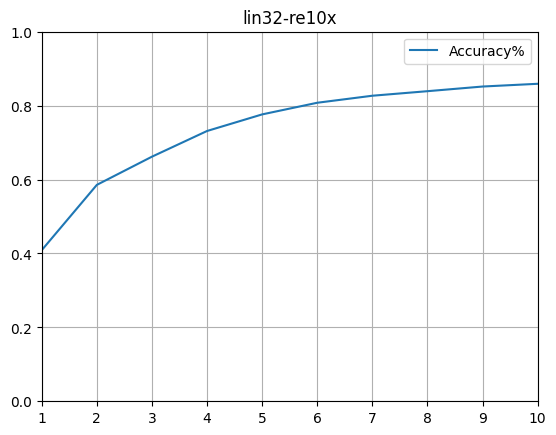

In [7]:
num_epochs = 10
sim_name = f"lin32-re{num_epochs}x"

print(f"{sim_name}")
accuracies = np.zeros(num_epochs)
losses = np.zeros(num_epochs)

for i in range(num_epochs):
    train()
    loss, acc = test()
    accuracies[i] = acc
    losses[i] = loss
    print(f"\tEpoch {i+1}: Accuracy= {(100*acc):>0.1f}%, AvgLoss= {loss:>8f}")

xrange = range(1, num_epochs+1)
plt.plot(xrange, accuracies, label="Accuracy%")
plt.xticks(xrange)
plt.xlim(1, num_epochs)
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.title(sim_name)
plt.savefig(f"figures/{sim_name}.png")
plt.show()

Now we are going to let us input our own hand-drawn digits to the model. Very simple using raylib.

In [8]:
from pyray import *

init_window(784, 784, "Torch Handwritten Digits")
inputdata = torch.zeros(1, 1, 28, 28, dtype=torch.float32)

for (X,y) in train_dataloader:
    inputdata = X[0].unsqueeze(0)
    break

inputdata = inputdata.to(device)
cw = 28
inference_timer=0
guesses=np.zeros(10)
top_guess = 0
model.eval()

def set_pixel(x: int, y: int, val: int):
    pass
    if (x >= 0 and x < 28 and y >= 0 and y < 28):
        inputdata[0,0,y,x] = val

def set_square(x: int, y: int, val: int):
    for dx in range(-1, 1):
        for dy in range(-1, 1):
            set_pixel(x+dx, y+dy, val)

while not window_should_close():
    inference_timer += get_frame_time()
    if (inference_timer > 1):
        inference_timer = 0
        pred = torch.softmax(model(inputdata), dim=1)
        guesses = pred.squeeze(0).detach().cpu().numpy()

    begin_drawing()
    clear_background(BLACK)

    mx = int(clamp(0, get_mouse_x() / cw, 27))
    my = int(clamp(0, get_mouse_y() / cw, 27))

    for x in range(28):
        for y in range(28):
            draw_rectangle(x * cw, y * cw, cw, cw, fade(WHITE, inputdata[0,0,y,x]))

    draw_rectangle(mx*cw,my*cw, cw, cw, Color(60,60,60,255))
    if is_mouse_button_down(MouseButton.MOUSE_BUTTON_LEFT):
        set_square(mx, my, 1)
    if is_mouse_button_down(MouseButton.MOUSE_BUTTON_RIGHT):
        set_square(mx, my, 0)
    if is_key_pressed(KeyboardKey.KEY_SPACE):
        inputdata.zero_()
    if is_key_pressed(KeyboardKey.KEY_R):
        inputdata = training_data[random.randint(0, 1000)][0].unsqueeze(0).to(device)

    draw_text("Torch Handwritten Digits", 10, 10, 20,  BLUE)
    draw_text(f"{mx}, {my}", 10, 30, 20,  BLUE)
    draw_text(f"{top_guess}", 700, 20, 100, BLUE)

    top_guess = np.argmax(guesses, 0)
    for i in range(10):
        val = guesses[i]
        draw_text(f"{i}", 307 + i * 30, 10, 25, BLUE)
        draw_rectangle_lines(300 + i * 30, 35, 25, 100, BLUE)
        draw_rectangle(300 + i * 30, 35, 25, int(val * 100), BLUE)
    end_drawing()
close_window()

RAYLIB STATIC 5.5.0.4 LOADED
